Python: 3.13.3 (v3.13.3:6280bb54784, Apr  8 2025, 10:47:54) [Clang 15.0.0 (clang-1500.3.9.4)]

numpy: 2.2.6

pandas: 2.3.3

sklearn: 1.8.0

matplotlib: 3.10.9

seaborn: 0.13.2

yfinance: 0.2.65

quantstats: 0.0.81

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yfinance as yf
import quantstats as qs

In [38]:
# ==========================================
# ENVIRONMENT INFO
# ==========================================

import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns

print("Python:", sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("yfinance:", yf.__version__)
print("quantstats:", qs.__version__)

Python: 3.13.3 (v3.13.3:6280bb54784, Apr  8 2025, 10:47:54) [Clang 15.0.0 (clang-1500.3.9.4)]
numpy: 2.2.6
pandas: 2.3.3
sklearn: 1.8.0
matplotlib: 3.10.9
seaborn: 0.13.2
yfinance: 0.2.65
quantstats: 0.0.81


In [2]:
spx = yf.download(
    'SPY',
    start='1993-01-01',
    end='2026-05-09',
    auto_adjust=True
)

# If yfinance returns MultiIndex columns, flatten them
if isinstance(spx.columns, pd.MultiIndex):
    close_price = spx['Close']['SPY']
    volume = spx['Volume']['SPY']
else:
    close_price = spx['Close']
    volume = spx['Volume']

close_price = close_price.squeeze()
volume = volume.squeeze()

spx_returns = close_price.pct_change()
benchmark_returns = spx_returns.copy()

[*********************100%***********************]  1 of 1 completed


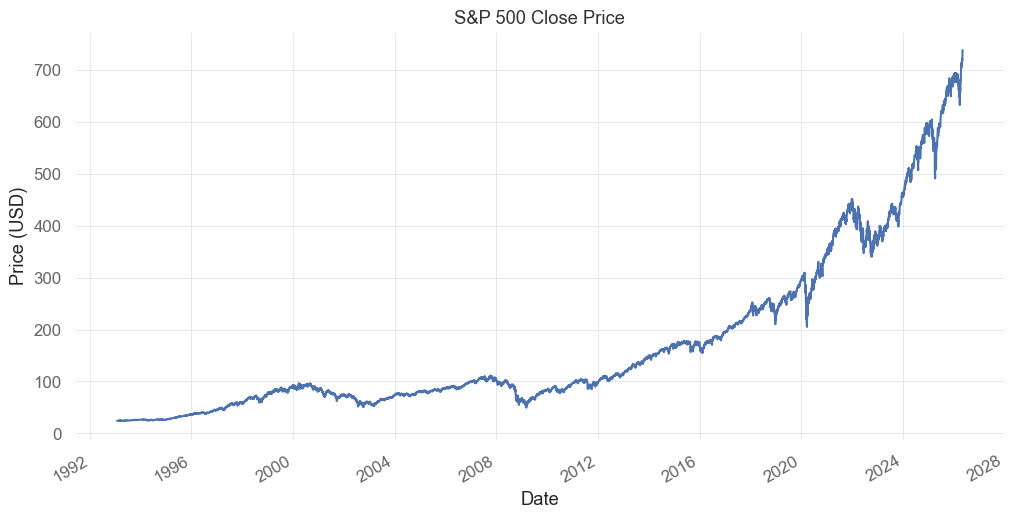

In [3]:
close_price.plot(figsize=(12, 6))
plt.title('S&P 500 Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

## Example:

Moving average Crossover strategy:

short term moving average, long term movinf average

We generate signal when the short-term moving average crosses above the long term moving average and sell when it corsses below. Toy model how to run a backtest

In [4]:
def make_ma_signal(close_price, short_window=50, long_window=252, long_only=False, ma_type="sma"):
    if ma_type == "sma":
        short_ma = close_price.rolling(short_window, min_periods=short_window).mean()
        long_ma = close_price.rolling(long_window, min_periods=long_window).mean()

    elif ma_type == "ema":
        short_ma = close_price.ewm(span=short_window, min_periods=short_window, adjust=False).mean()
        long_ma = close_price.ewm(span=long_window, min_periods=long_window, adjust=False).mean()

    else:
        raise ValueError("ma_type must be 'sma' or 'ema'")

    signal = pd.Series(0.0, index=close_price.index)

    if long_only:
        signal[short_ma > long_ma] = 1.0
        signal[short_ma <= long_ma] = 0.0
    else:
        signal[short_ma > long_ma] = 1.0
        signal[short_ma < long_ma] = -1.0

    signals = pd.DataFrame(index=close_price.index)
    signals['short_ma'] = short_ma
    signals['long_ma'] = long_ma
    signals['signal'] = signal

    return signals

In [5]:
close_price.info

<bound method Series.info of Date
1993-01-29     24.175383
1993-02-01     24.347326
1993-02-02     24.398895
1993-02-03     24.656820
1993-02-04     24.760002
                 ...    
2026-05-04    718.010010
2026-05-05    723.770020
2026-05-06    733.830017
2026-05-07    731.580017
2026-05-08    737.619995
Name: SPY, Length: 8376, dtype: float64>

In [6]:
signals = make_ma_signal(
    close_price,
    short_window=50,
    long_window=252,
    long_only=False,
    ma_type="sma"
)

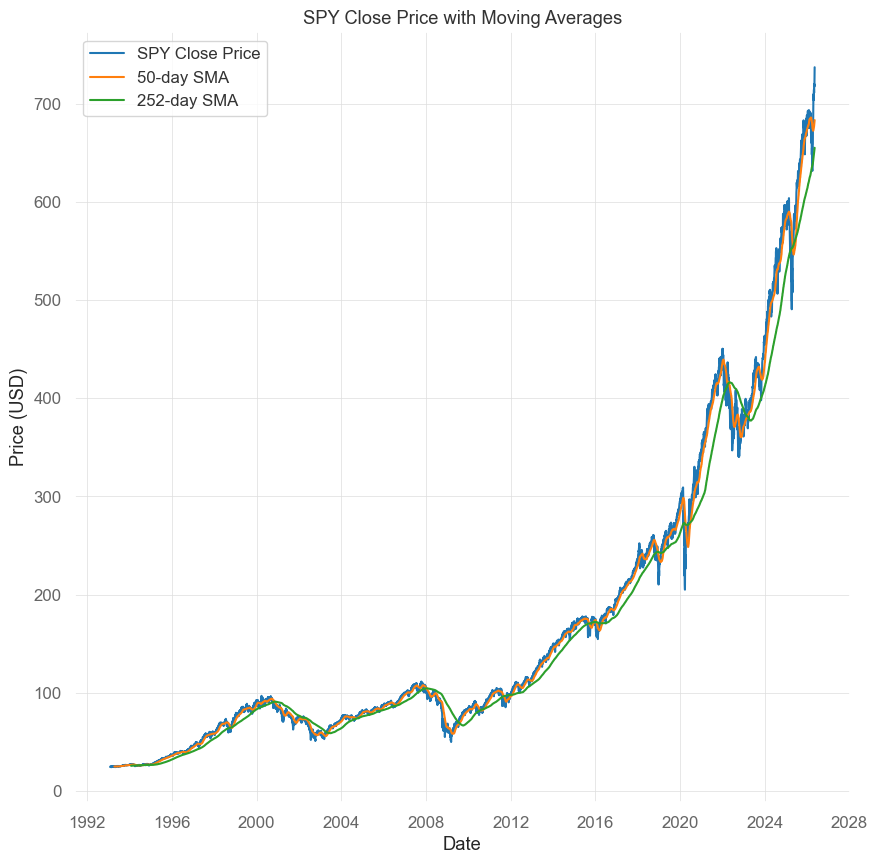

In [7]:
plt.figure(figsize=(10, 10))
plt.plot(close_price.index, close_price, label='SPY Close Price', color='#1f77b4')
plt.plot(signals.index, signals['short_ma'], label='50-day SMA', color='#ff7f0e')
plt.plot(signals.index, signals['long_ma'], label='252-day SMA', color='#2ca02c')
plt.title('SPY Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
#plt.grid(on=True)
plt.show()

## Step 2: Crafting effective signal

negative values - bearish (-1 to -0.001)

positive - bullish (0.001 to 1)

around 0 - uncertain, lacks enough conviction

In [8]:
def apply_vol_target(signal, returns, target_vol=0.15, vol_window=22, max_leverage=2.0):
    realized_vol = returns.rolling(vol_window).std() * np.sqrt(252)

    vol_scale = target_vol / realized_vol
    vol_scale = vol_scale.clip(lower=0, upper=max_leverage)

    position = signal.shift(1) * vol_scale.shift(1)

    strategy_returns = returns * position

    return position, strategy_returns, realized_vol, vol_scale

In [9]:
position, strategy_voltgt_returns, realized_vol, vol_scale = apply_vol_target(
    signal=signals['signal'],
    returns=spx_returns,
    target_vol=0.15,
    vol_window=22,
    max_leverage=2.0
)

In [10]:
turnover = position.diff().abs()

In [11]:
daily_value = close_price * volume

participation = 1_000_000 / daily_value
participation = participation.clip(upper=0.01)

In [12]:
brokerage_fee = 0.0002      # 2 bps, not 20 bps
bid_ask_fee = 0.000032      # 0.32 bps
slippage_at_1pct_adv = 0.0010  # 10 bps when participation = 1%

brokerage = turnover * brokerage_fee
spread = turnover * bid_ask_fee

slippage_cost_per_turnover = (participation / 0.01) * slippage_at_1pct_adv
slippage = turnover * slippage_cost_per_turnover

total_costs = brokerage + spread + slippage
after_cost = strategy_voltgt_returns - total_costs

In [13]:
def perf_stats(r):
    r = r.dropna()

    return pd.Series({
        "Total Return": (1 + r).prod() - 1,
        "CAGR": qs.stats.cagr(r),
        "Volatility": qs.stats.volatility(r),
        "Sharpe": qs.stats.sharpe(r),
        "Sortino": qs.stats.sortino(r),
        "Max Drawdown": qs.stats.max_drawdown(r),
        "Calmar": qs.stats.calmar(r),
    })

In [14]:
summary = pd.DataFrame({
    "Buy & Hold SPY": perf_stats(benchmark_returns),
    "MA Strategy Before Costs": perf_stats(strategy_voltgt_returns),
    "MA Strategy After Costs": perf_stats(after_cost),
}).T

display(summary)

,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Buy & Hold SPY,29.511203,0.108324,0.185896,0.646362,0.919840,-0.551894,0.196277
MA Strategy Before Costs,25.061031,0.103364,0.160272,0.694250,0.963525,-0.349523,0.295728
MA Strategy After Costs,21.787082,0.098917,0.160284,0.669005,0.927422,-0.353008,0.280211


In [15]:
benchmark=benchmark_returns


Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               1994-01-27   1994-01-27
End Period                 2026-05-08   2026-05-08
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          2,664.05%    2,178.71%
CAGR﹪                     10.84%       10.18%

Sharpe                     0.64         0.68
Prob. Sharpe Ratio         99.99%       99.99%
Smart Sharpe               0.62         0.65
Sortino                    0.91         0.94
Smart Sortino              0.88         0.91
Sortino/√2                 0.65         0.66
Smart Sortino/√2           0.62         0.64
Omega                      1.13         1.12

Max Drawdown               -55.19%      -35.3%
Max DD Date                2009-03-09   

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2014-12-08,2016-06-27,2017-11-27,1086,-35.300770,-33.670696
2,1994-02-03,1994-12-08,1995-07-06,519,-31.726969,-31.002999
3,2018-09-21,2020-06-08,2021-04-23,946,-28.493963,-26.351742
4,2011-05-02,2012-06-04,2013-04-09,709,-22.966795,-21.809628
5,1998-07-20,1998-11-17,2001-02-20,947,-20.476548,-19.988655


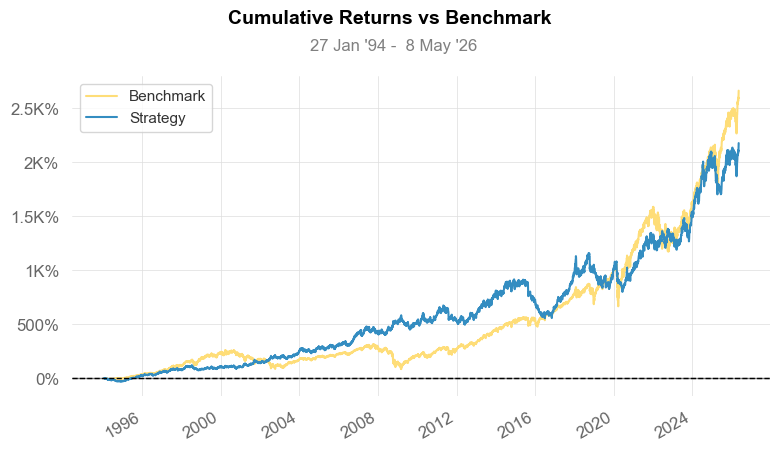

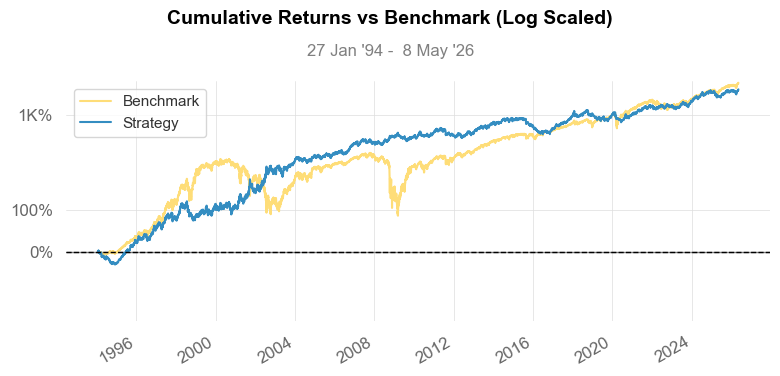

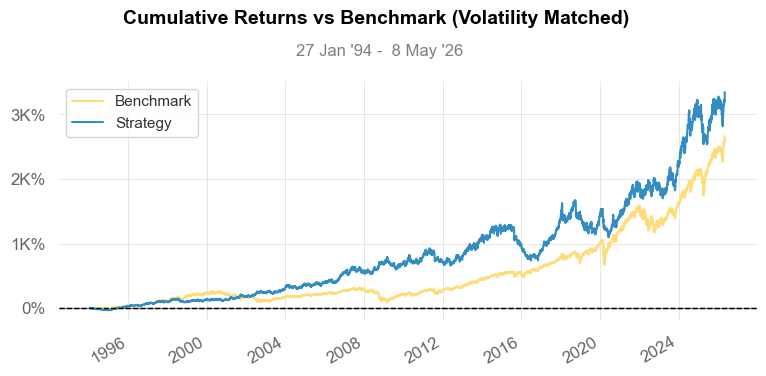

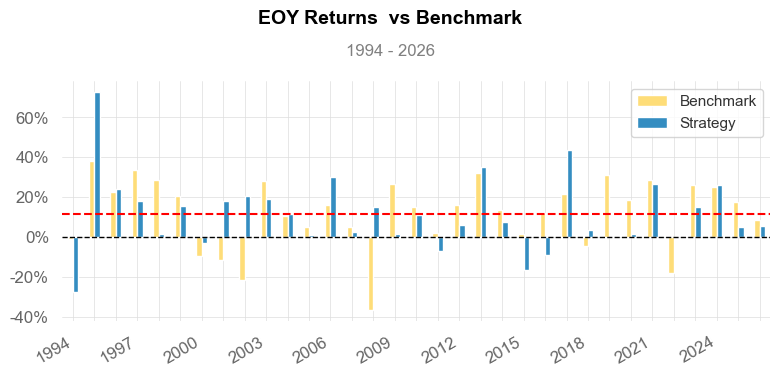

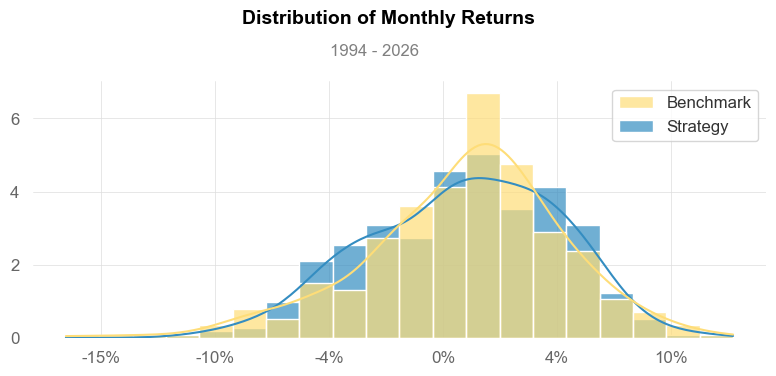

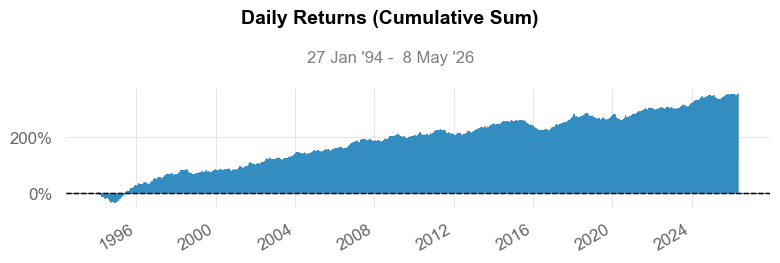

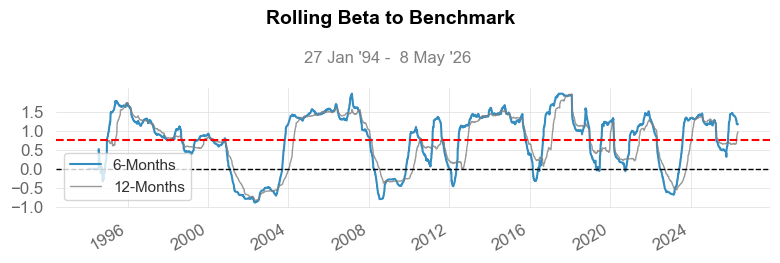

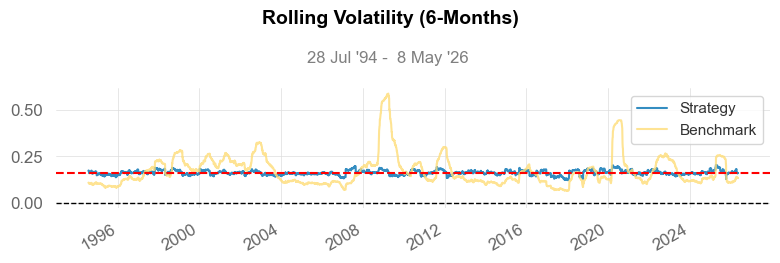

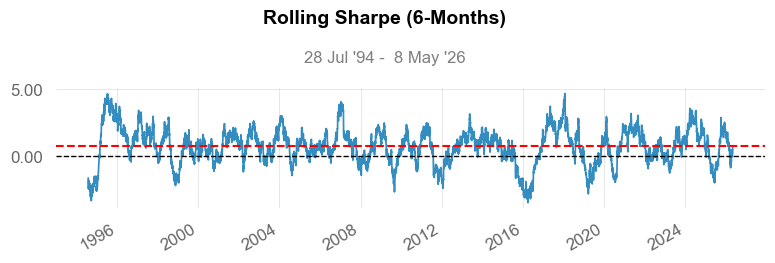

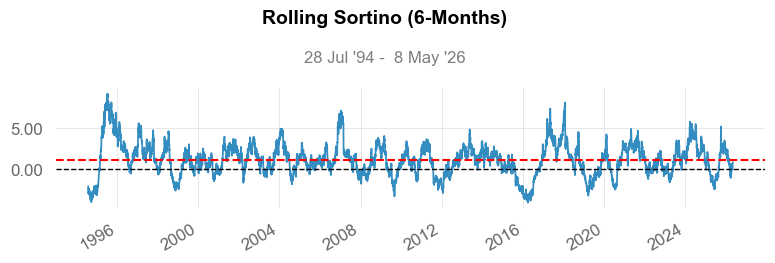

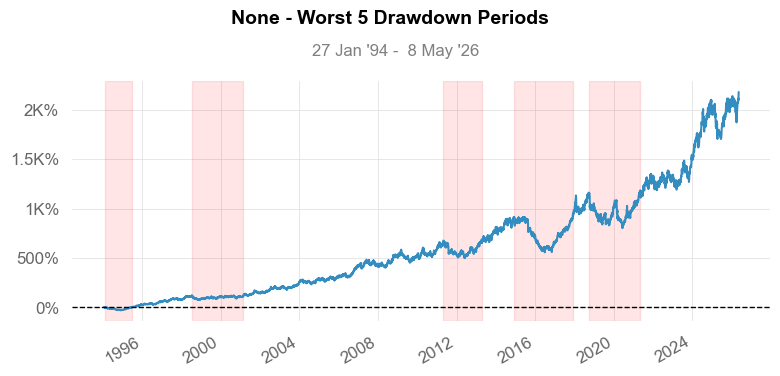

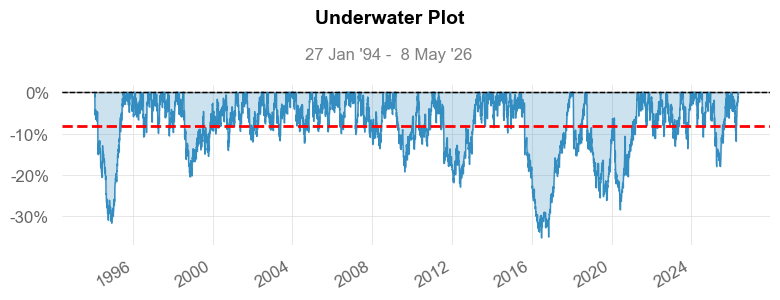

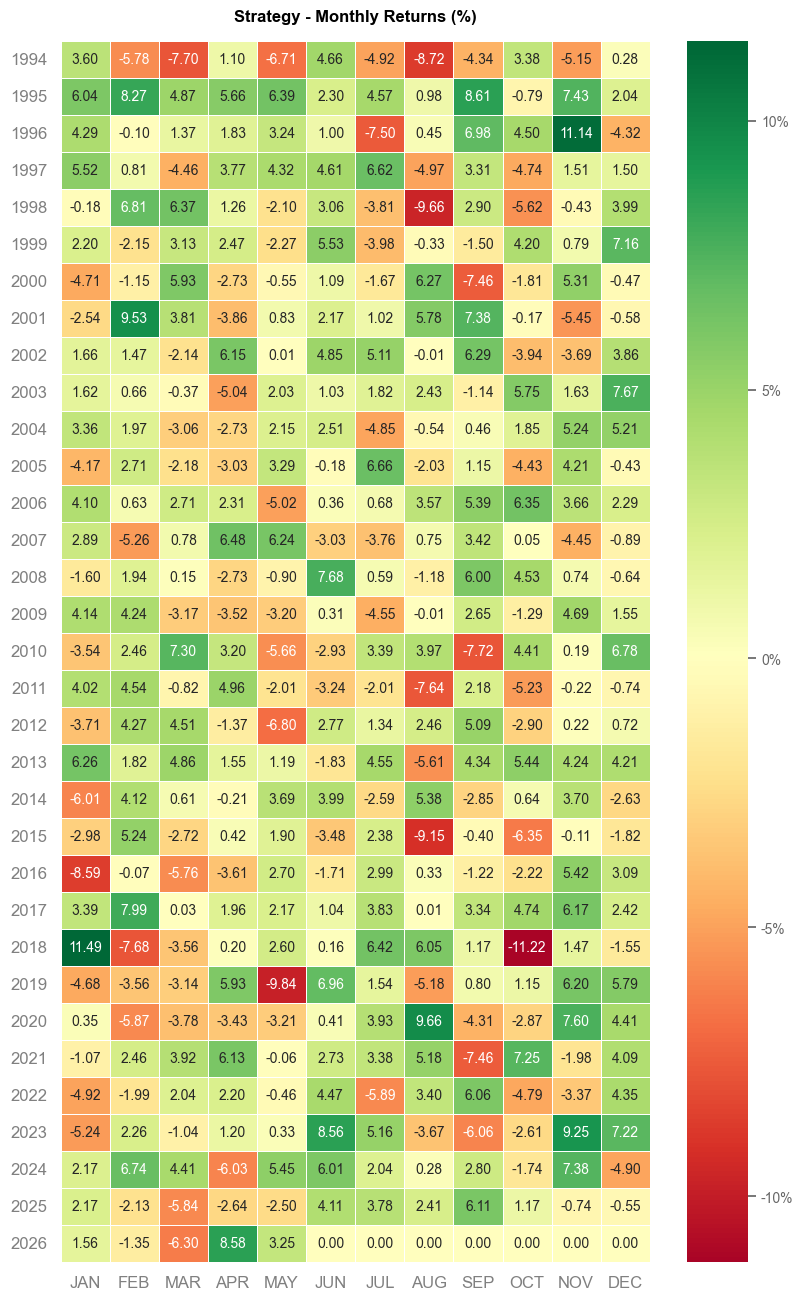

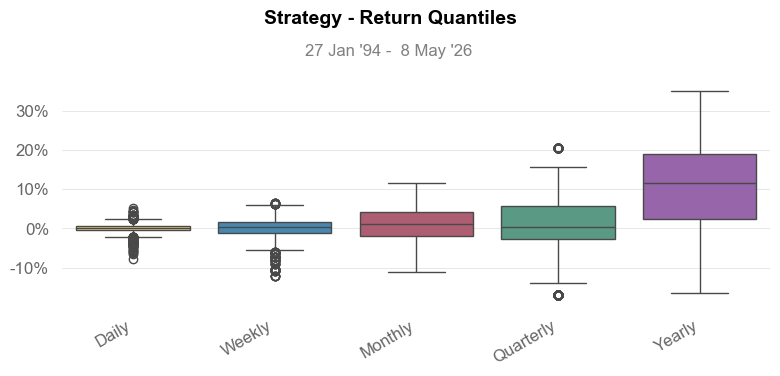

In [16]:
qs.reports.full(
    returns=after_cost.dropna(),
    benchmark=benchmark_returns.dropna(),
    output='report_after_costs.html',
    title='MA Strategy After Costs vs Buy-and-Hold SPY'
)

In [17]:
signals_long_only = make_ma_signal(
    close_price,
    short_window=50,
    long_window=252,
    long_only=True,
    ma_type="sma"
)

position_long_only, strategy_long_only, _, _ = apply_vol_target(
    signal=signals_long_only['signal'],
    returns=spx_returns,
    target_vol=0.15,
    vol_window=22,
    max_leverage=2.0
)

turnover_long_only = position_long_only.diff().abs()

brokerage_lo = turnover_long_only * brokerage_fee
spread_lo = turnover_long_only * bid_ask_fee
slippage_lo = turnover_long_only * slippage_cost_per_turnover

total_costs_lo = brokerage_lo + spread_lo + slippage_lo
after_cost_long_only = strategy_long_only - total_costs_lo

In [18]:
summary = pd.DataFrame({
    "Buy & Hold SPY": perf_stats(benchmark_returns),
    "Long/Short Before Costs": perf_stats(strategy_voltgt_returns),
    "Long/Short After Costs": perf_stats(after_cost),
    "Long-Only After Costs": perf_stats(after_cost_long_only),
}).T

display(summary)

,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Buy & Hold SPY,29.511203,0.108324,0.185896,0.646362,0.919840,-0.551894,0.196277
Long/Short Before Costs,25.061031,0.103364,0.160272,0.694250,0.963525,-0.349523,0.295728
Long/Short After Costs,21.787082,0.098917,0.160284,0.669005,0.927422,-0.353008,0.280211
Long-Only After Costs,27.399511,0.106241,0.143654,0.775125,1.067217,-0.235670,0.450806


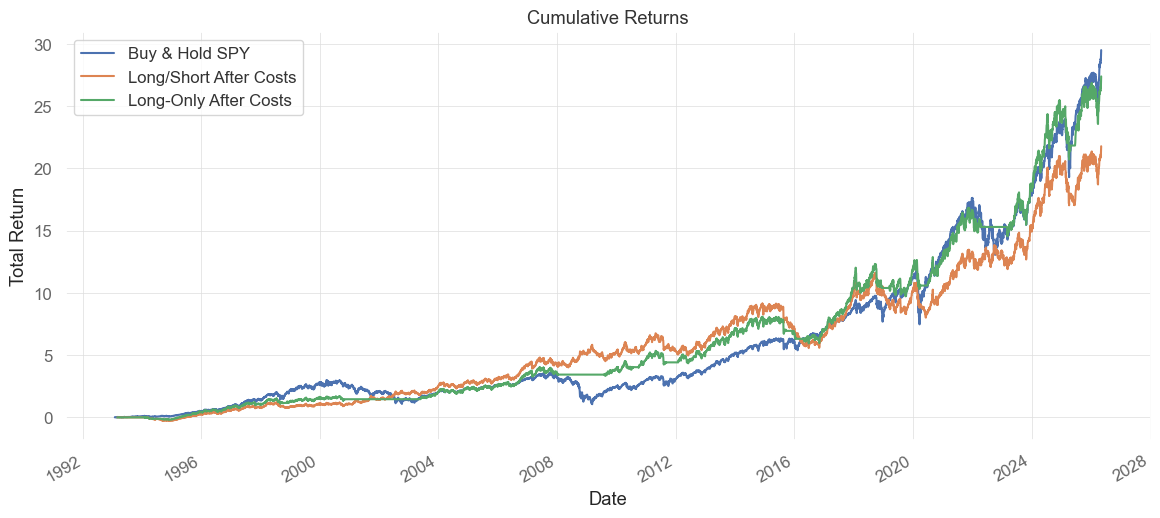

In [19]:
cum = pd.DataFrame({
    "Buy & Hold SPY": (1 + benchmark_returns).cumprod() - 1,
    "Long/Short After Costs": (1 + after_cost).cumprod() - 1,
    "Long-Only After Costs": (1 + after_cost_long_only).cumprod() - 1,
})

cum.plot(figsize=(14, 6), title="Cumulative Returns")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()

In [20]:
short_windows = [20, 50, 63, 100]
long_windows = [126, 200, 252, 300]

results = []

for sw in short_windows:
    for lw in long_windows:
        if sw >= lw:
            continue

        sig = make_ma_signal(
            close_price,
            short_window=sw,
            long_window=lw,
            long_only=True,
            ma_type="sma"
        )

        pos, strat_ret, _, _ = apply_vol_target(
            sig['signal'],
            spx_returns,
            target_vol=0.15,
            vol_window=22,
            max_leverage=2.0
        )

        t = pos.diff().abs()

        costs = (
            t * brokerage_fee
            + t * bid_ask_fee
            + t * slippage_cost_per_turnover
        )

        net_ret = strat_ret - costs
        stats = perf_stats(net_ret)

        results.append({
            "short_window": sw,
            "long_window": lw,
            "CAGR": stats["CAGR"],
            "Sharpe": stats["Sharpe"],
            "Max Drawdown": stats["Max Drawdown"],
            "Total Return": stats["Total Return"],
            "Avg Turnover": t.mean(),
        })

robustness = pd.DataFrame(results)
display(robustness.sort_values("Sharpe", ascending=False))

,short_window,long_window,CAGR,Sharpe,Max Drawdown,Total Return,Avg Turnover
15,100,300,0.110116,0.797947,-0.204229,30.888341,0.032331
3,20,300,0.109955,0.793968,-0.212771,30.735907,0.034053
11,63,300,0.108315,0.786168,-0.227008,29.217878,0.032335
7,50,300,0.107982,0.782268,-0.262699,28.918366,0.032739
6,50,252,0.106241,0.775125,-0.235670,27.399511,0.032955
5,50,200,0.104423,0.766091,-0.232466,25.892389,0.033026
1,20,200,0.101913,0.749495,-0.222502,23.939274,0.036269
14,100,252,0.101595,0.745647,-0.227553,23.701814,0.032315
2,20,252,0.100382,0.735693,-0.220104,22.816173,0.035001
10,63,252,0.098890,0.730154,-0.257689,21.768755,0.032820


In [21]:
split_date = "2011-01-01"

train = after_cost.loc[:split_date]
test = after_cost.loc[split_date:]

summary_oos = pd.DataFrame({
    "Train": perf_stats(train),
    "Test": perf_stats(test),
    "BuyHold Test": perf_stats(benchmark_returns.loc[split_date:]),
}).T

display(summary_oos)

,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Train,5.853705,0.114026,0.157140,0.766043,1.083470,-0.317270,0.359397
Test,2.324783,0.081592,0.163881,0.560972,0.761858,-0.353008,0.231133
BuyHold Test,6.688637,0.142438,0.170986,0.864717,1.218572,-0.337173,0.422448


## Research Hypothesis

This project tests whether SPY exhibits medium-term time-series momentum using a moving-average crossover strategy. The strategy uses lagged signals to avoid look-ahead bias, volatility targeting to stabilize annualized risk, and explicit transaction costs including brokerage, bid-ask spread, and participation-based slippage. Performance is compared against buy-and-hold SPY, with additional robustness checks across moving-average windows and an out-of-sample split.

In [22]:
def run_strategy(
    close_price,
    volume,
    short_window=50,
    long_window=252,
    long_only=True,
    ma_type="sma",
    target_vol=0.15,
    vol_window=22,
    max_leverage=2.0,
    max_trade_usd=1_000_000,
    max_participation=0.01,
    brokerage_fee=0.0002,
    bid_ask_fee=0.000032,
    slippage_at_1pct_adv=0.0010,
):
    returns = close_price.pct_change()

    signals = make_ma_signal(
        close_price=close_price,
        short_window=short_window,
        long_window=long_window,
        long_only=long_only,
        ma_type=ma_type,
    )

    position, gross_returns, realized_vol, vol_scale = apply_vol_target(
        signal=signals["signal"],
        returns=returns,
        target_vol=target_vol,
        vol_window=vol_window,
        max_leverage=max_leverage,
    )

    turnover = position.diff().abs()

    daily_value = close_price * volume
    participation = max_trade_usd / daily_value
    participation = participation.clip(upper=max_participation)

    slippage_cost_per_turnover = (
        participation / max_participation
    ) * slippage_at_1pct_adv

    costs = (
        turnover * brokerage_fee
        + turnover * bid_ask_fee
        + turnover * slippage_cost_per_turnover
    )

    net_returns = gross_returns - costs

    return {
        "net_returns": net_returns,
        "gross_returns": gross_returns,
        "position": position,
        "turnover": turnover,
        "costs": costs,
        "signals": signals,
    }

In [23]:
def select_best_params(
    train_close,
    train_volume,
    short_windows,
    long_windows,
    metric="Sharpe",
    long_only=True,
    ma_type="sma",
):
    results = []

    for sw in short_windows:
        for lw in long_windows:
            if sw >= lw:
                continue

            out = run_strategy(
                close_price=train_close,
                volume=train_volume,
                short_window=sw,
                long_window=lw,
                long_only=long_only,
                ma_type=ma_type,
            )

            r = out["net_returns"].dropna()

            if len(r) < 252:
                continue

            stats = perf_stats(r)

            max_dd_abs = abs(stats["Max Drawdown"])

            score = stats["Sharpe"] - 0.5 * max_dd_abs
            # larger Sharpe good, larger drawdown bad

            results.append({
                "short_window": sw,
                "long_window": lw,
                "CAGR": stats["CAGR"],
                "Sharpe": stats["Sharpe"],
                "Max Drawdown": stats["Max Drawdown"],
                "Total Return": stats["Total Return"],
                "Avg Turnover": out["turnover"].mean(),
                "Score": score,
            })

    results = pd.DataFrame(results)

    if results.empty:
        return None, results

    # best_row = results.sort_values(metric, ascending=False).iloc[0]
    best_row = results.sort_values("Score", ascending=False).iloc[0]

    best_params = {
        "short_window": int(best_row["short_window"]),
        "long_window": int(best_row["long_window"]),
    }

    return best_params, results

In [24]:
def walk_forward_backtest(
    close_price,
    volume,
    short_windows,
    long_windows,
    train_years=5,
    test_years=1,
    start_date=None,
    end_date=None,
    long_only=True,
    ma_type="sma",
):
    close_price = close_price.dropna()
    volume = volume.reindex(close_price.index).dropna()

    common_index = close_price.index.intersection(volume.index)
    close_price = close_price.loc[common_index]
    volume = volume.loc[common_index]

    if start_date is None:
        start_date = close_price.index.min()
    else:
        start_date = pd.Timestamp(start_date)

    if end_date is None:
        end_date = close_price.index.max()
    else:
        end_date = pd.Timestamp(end_date)

    wf_returns = []
    wf_rows = []
    all_param_results = {}

    train_start = start_date
    train_end = train_start + pd.DateOffset(years=train_years)

    fold = 1

    while True:
        test_start = train_end
        test_end = test_start + pd.DateOffset(years=test_years)

        if test_start >= end_date:
            break

        if test_end > end_date:
            test_end = end_date

        train_mask = (close_price.index >= train_start) & (close_price.index < train_end)
        test_mask = (close_price.index >= test_start) & (close_price.index < test_end)

        train_close = close_price.loc[train_mask]
        train_volume = volume.loc[train_mask]

        test_close = close_price.loc[test_mask]
        test_volume = volume.loc[test_mask]

        if len(train_close) < 252 * 2 or len(test_close) < 50:
            break

        best_params, param_results = select_best_params(
            train_close=train_close,
            train_volume=train_volume,
            short_windows=short_windows,
            long_windows=long_windows,
            metric="Sharpe",
            long_only=long_only,
            ma_type=ma_type,
        )

        all_param_results[fold] = param_results

        if best_params is None:
            break

        # Important:
        # To calculate moving averages correctly in the test window,
        # include training history before the test period.
        combined_close = close_price.loc[
            (close_price.index >= train_start) & (close_price.index < test_end)
        ]

        combined_volume = volume.loc[combined_close.index]

        out = run_strategy(
            close_price=combined_close,
            volume=combined_volume,
            short_window=best_params["short_window"],
            long_window=best_params["long_window"],
            long_only=long_only,
            ma_type=ma_type,
        )

        test_net_returns = out["net_returns"].loc[test_close.index]
        wf_returns.append(test_net_returns)

        wf_rows.append({
            "fold": fold,
            "train_start": train_start,
            "train_end": train_end,
            "test_start": test_start,
            "test_end": test_end,
            "short_window": best_params["short_window"],
            "long_window": best_params["long_window"],
            "test_CAGR": qs.stats.cagr(test_net_returns.dropna()),
            "test_Sharpe": qs.stats.sharpe(test_net_returns.dropna()),
            "test_MaxDD": qs.stats.max_drawdown(test_net_returns.dropna()),
            "test_TotalReturn": (1 + test_net_returns.dropna()).prod() - 1,
        })

        fold += 1

        train_start = train_start + pd.DateOffset(years=test_years)
        train_end = train_start + pd.DateOffset(years=train_years)

    wf_returns = pd.concat(wf_returns).sort_index()
    wf_summary = pd.DataFrame(wf_rows)

    return wf_returns, wf_summary, all_param_results

In [25]:
short_windows = [20, 50, 63, 100]
long_windows = [126, 200, 252, 300]

wf_returns, wf_summary, wf_param_results = walk_forward_backtest(
    close_price=close_price,
    volume=volume,
    short_windows=short_windows,
    long_windows=long_windows,
    train_years=5,
    test_years=1,
    start_date="1993-01-01",
    end_date="2026-05-01",
    long_only=True,
    ma_type="sma",
)

display(wf_summary)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/quantstats/stats.py:892: RuntimeWarning: invalid value encountered in scalar divide
  res = returns.mean() / divisor
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/quantstats/stats.py:892: RuntimeWarning: invalid value encountered in scalar divide
  res = returns.mean() / divisor


,fold,train_start,train_end,test_start,test_end,short_window,long_window,test_CAGR,test_Sharpe,test_MaxDD,test_TotalReturn
0,1,1993-01-01,1998-01-01,1998-01-01,1999-01-01,63,300,0.174184,1.036985,-0.162513,0.174184
1,2,1994-01-01,1999-01-01,1999-01-01,2000-01-01,100,252,0.156221,1.033623,-0.114194,0.156221
2,3,1995-01-01,2000-01-01,2000-01-01,2001-01-01,63,126,-0.075616,-0.417839,-0.135667,-0.075616
3,4,1996-01-01,2001-01-01,2001-01-01,2002-01-01,63,200,0.000000,NaN,0.000000,0.000000
4,5,1997-01-01,2002-01-01,2002-01-01,2003-01-01,100,252,0.000000,NaN,0.000000,0.000000
5,6,1998-01-01,2003-01-01,2003-01-01,2004-01-01,50,252,0.248001,1.962249,-0.051849,0.248001
6,7,1999-01-01,2004-01-01,2004-01-01,2005-01-01,63,200,0.064651,0.519953,-0.123018,0.064651
7,8,2000-01-01,2005-01-01,2005-01-01,2006-01-01,20,300,0.009007,0.135596,-0.095451,0.009007
8,9,2001-01-01,2006-01-01,2006-01-01,2007-01-01,20,300,0.301592,1.821905,-0.099754,0.300232
9,10,2002-01-01,2007-01-01,2007-01-01,2008-01-01,20,300,0.024086,0.223804,-0.109249,0.023989


In [26]:
wf_benchmark = benchmark_returns.reindex(wf_returns.index)

wf_comparison = pd.DataFrame({
    "Walk-Forward Strategy": perf_stats(wf_returns),
    "Buy & Hold SPY": perf_stats(wf_benchmark),
}).T

display(wf_comparison)

,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Walk-Forward Strategy,8.531932,0.083009,0.143014,0.629489,0.860343,-0.271778,0.305430
Buy & Hold SPY,11.067051,0.092080,0.194024,0.551105,0.782465,-0.551894,0.166844


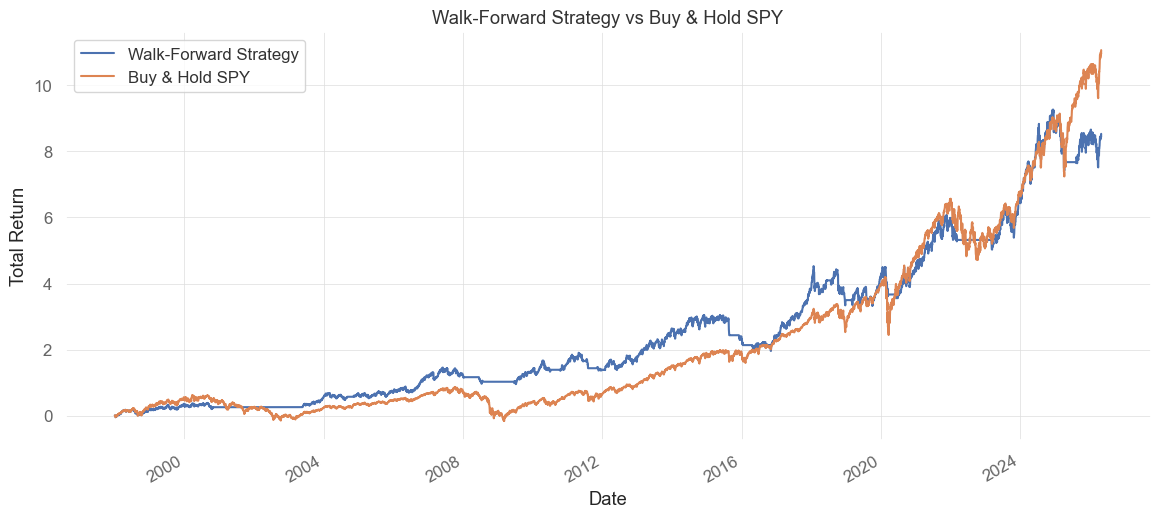

In [27]:
cum_wf = pd.DataFrame({
    "Walk-Forward Strategy": (1 + wf_returns).cumprod() - 1,
    "Buy & Hold SPY": (1 + wf_benchmark).cumprod() - 1,
})

cum_wf.plot(figsize=(14, 6), title="Walk-Forward Strategy vs Buy & Hold SPY")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()

In [28]:
wf_summary[["fold", "test_start", "test_end", "short_window", "long_window", "test_Sharpe", "test_TotalReturn", "test_MaxDD"]]

,fold,test_start,test_end,short_window,long_window,test_Sharpe,test_TotalReturn,test_MaxDD
0,1,1998-01-01,1999-01-01,63,300,1.036985,0.174184,-0.162513
1,2,1999-01-01,2000-01-01,100,252,1.033623,0.156221,-0.114194
2,3,2000-01-01,2001-01-01,63,126,-0.417839,-0.075616,-0.135667
3,4,2001-01-01,2002-01-01,63,200,NaN,0.000000,0.000000
4,5,2002-01-01,2003-01-01,100,252,NaN,0.000000,0.000000
5,6,2003-01-01,2004-01-01,50,252,1.962249,0.248001,-0.051849
6,7,2004-01-01,2005-01-01,63,200,0.519953,0.064651,-0.123018
7,8,2005-01-01,2006-01-01,20,300,0.135596,0.009007,-0.095451
8,9,2006-01-01,2007-01-01,20,300,1.821905,0.300232,-0.099754
9,10,2007-01-01,2008-01-01,20,300,0.223804,0.023989,-0.109249


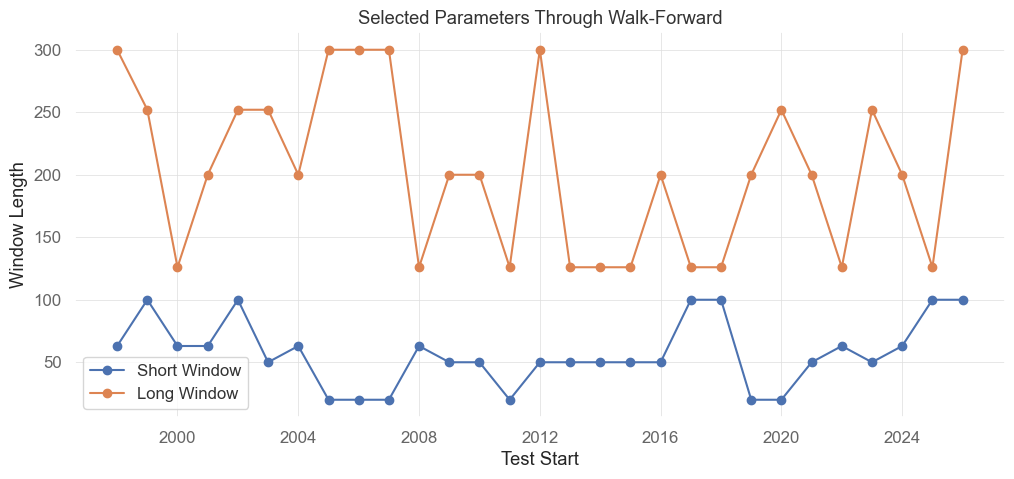

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(wf_summary["test_start"], wf_summary["short_window"], marker="o", label="Short Window")
plt.plot(wf_summary["test_start"], wf_summary["long_window"], marker="o", label="Long Window")
plt.title("Selected Parameters Through Walk-Forward")
plt.xlabel("Test Start")
plt.ylabel("Window Length")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
dd_compare = pd.DataFrame({
    "Walk-Forward Strategy": {
        "Max Drawdown": qs.stats.max_drawdown(wf_returns.dropna()),
        "CAGR": qs.stats.cagr(wf_returns.dropna()),
        "Sharpe": qs.stats.sharpe(wf_returns.dropna()),
        "Calmar": qs.stats.calmar(wf_returns.dropna()),
    },
    "Buy & Hold SPY": {
        "Max Drawdown": qs.stats.max_drawdown(wf_benchmark.dropna()),
        "CAGR": qs.stats.cagr(wf_benchmark.dropna()),
        "Sharpe": qs.stats.sharpe(wf_benchmark.dropna()),
        "Calmar": qs.stats.calmar(wf_benchmark.dropna()),
    }
}).T

display(dd_compare)

,Max Drawdown,CAGR,Sharpe,Calmar
Walk-Forward Strategy,-0.271778,0.083009,0.629489,0.305430
Buy & Hold SPY,-0.551894,0.092080,0.551105,0.166844


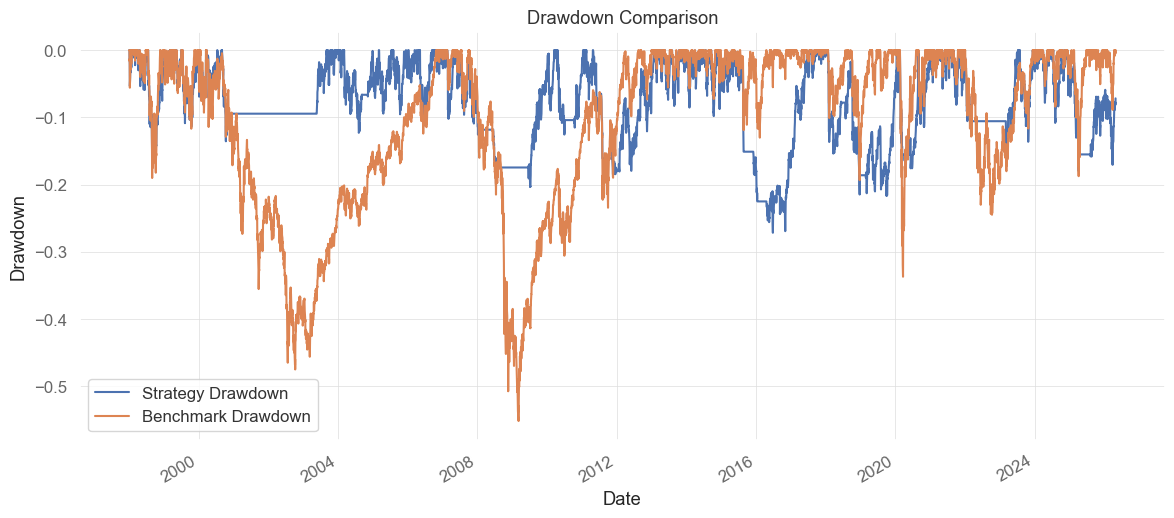

In [31]:
strategy_dd = qs.stats.to_drawdown_series(wf_returns.dropna())
benchmark_dd = qs.stats.to_drawdown_series(wf_benchmark.dropna())

dd = pd.DataFrame({
    "Strategy Drawdown": strategy_dd,
    "Benchmark Drawdown": benchmark_dd,
})

dd.plot(figsize=(14, 6), title="Drawdown Comparison")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

(29, 11)
['fold', 'train_start', 'train_end', 'test_start', 'test_end', 'short_window', 'long_window', 'test_CAGR', 'test_Sharpe', 'test_MaxDD', 'test_TotalReturn']


long_window,126,200,252,300
short_window,,,,
20,-0.468706,0.973372,0.453963,0.727102
50,0.484321,0.904894,1.691482,0.866196
63,-1.096933,0.993796,NaN,1.036985
100,0.804262,NaN,1.033623,0.431636


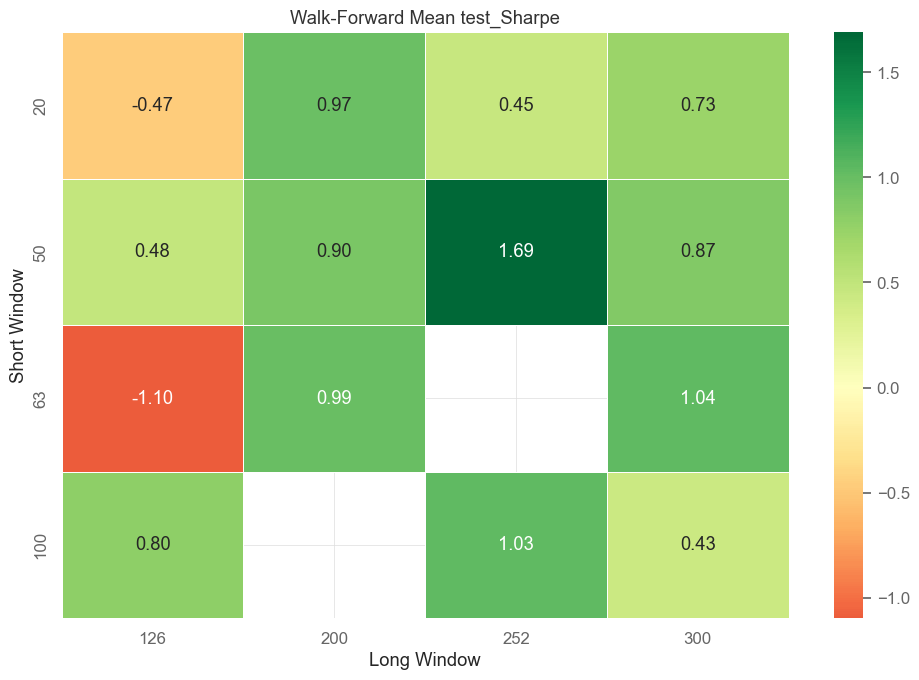

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

df = wf_summary.copy()

print(df.shape)
print(df.columns.tolist())

metric = "test_Sharpe"  # or "test_TotalReturn", "test_MaxDD"

pivot = df.pivot_table(
    index="short_window",
    columns="long_window",
    values=metric,
    aggfunc="mean"
)

display(pivot)

if pivot.empty:
    raise ValueError("Pivot is empty. Your wf_summary has no usable rows for this metric.")

plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title(f"Walk-Forward Mean {metric}")
plt.xlabel("Long Window")
plt.ylabel("Short Window")
plt.tight_layout()
plt.show()

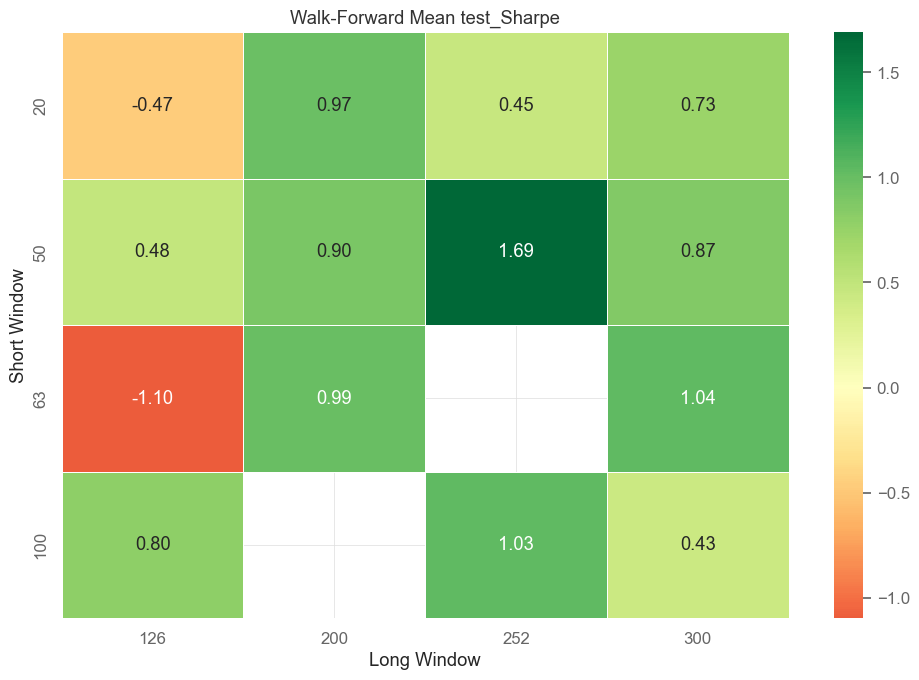

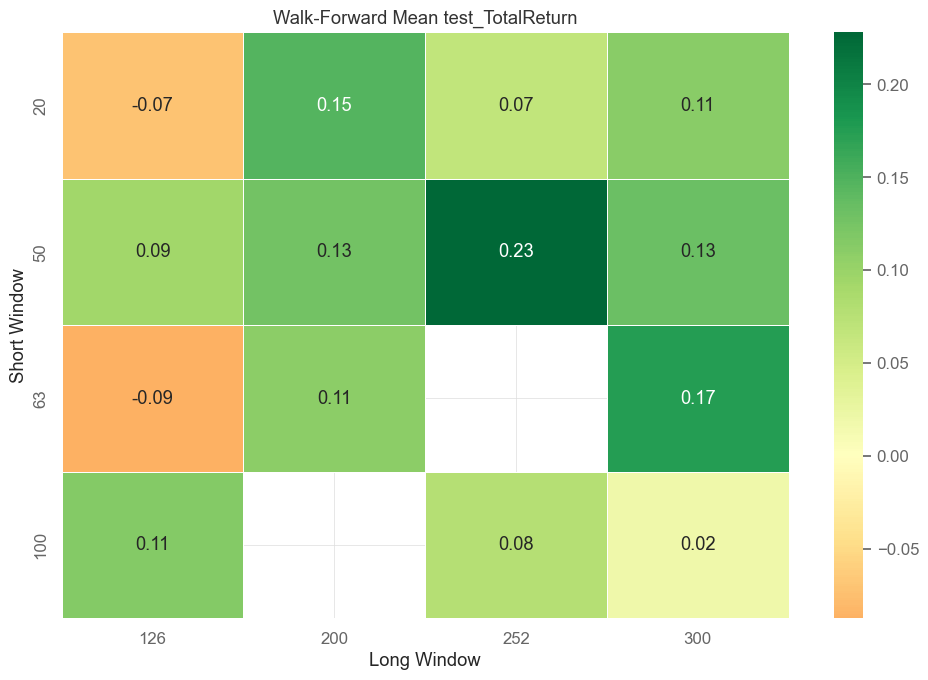

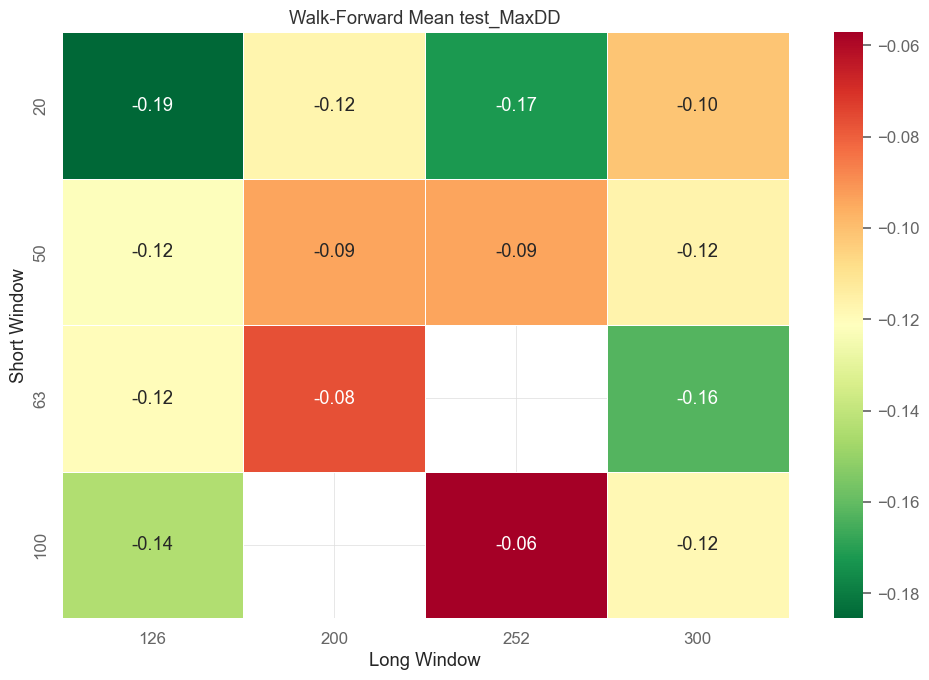

In [33]:
metrics = ["test_Sharpe", "test_TotalReturn", "test_MaxDD"]

for metric in metrics:
    pivot = wf_summary.pivot_table(
        index="short_window",
        columns="long_window",
        values=metric,
        aggfunc="mean"
    )

    if pivot.empty:
        print(f"Skipping {metric}: empty pivot")
        continue

    plt.figure(figsize=(10, 7))

    cmap = "RdYlGn_r" if metric == "test_MaxDD" else "RdYlGn"

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        center=0 if metric != "test_MaxDD" else None,
        linewidths=0.5
    )

    plt.title(f"Walk-Forward Mean {metric}")
    plt.xlabel("Long Window")
    plt.ylabel("Short Window")
    plt.tight_layout()
    plt.show()

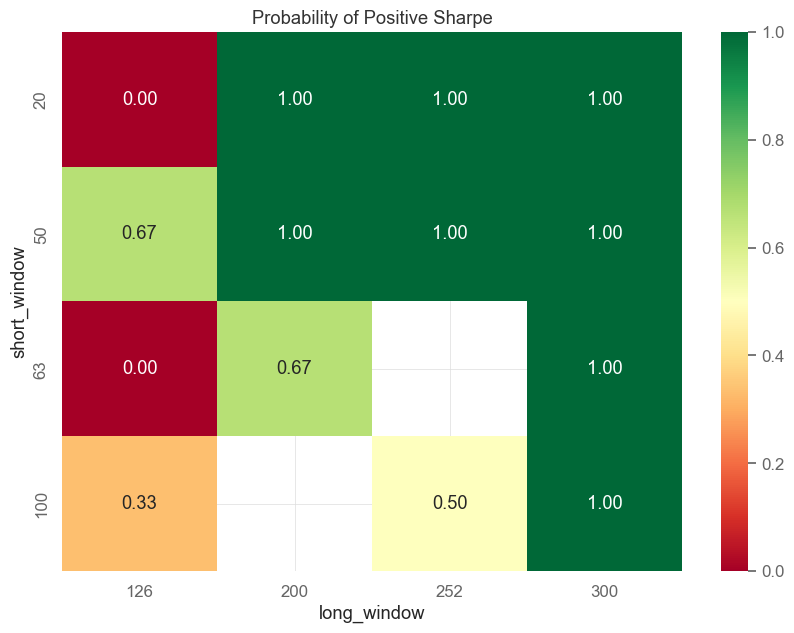

In [34]:
wf_summary["positive_sharpe"] = (
    wf_summary["test_Sharpe"] > 0
).astype(int)

pivot_prob = wf_summary.pivot_table(
    index="short_window",
    columns="long_window",
    values="positive_sharpe",
    aggfunc="mean"
)

plt.figure(figsize=(10,7))

sns.heatmap(
    pivot_prob,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1
)

plt.title("Probability of Positive Sharpe")
plt.show()

In [35]:
wf_summary[
    ["short_window", "long_window"]
].drop_duplicates().sort_values(
    ["short_window", "long_window"]
)

,short_window,long_window
13,20,126
21,20,200
22,20,252
7,20,300
15,50,126
11,50,200
5,50,252
14,50,300
2,63,126
3,63,200


In [36]:
display(
    robustness.sort_values("Sharpe", ascending=False)
)

,short_window,long_window,CAGR,Sharpe,Max Drawdown,Total Return,Avg Turnover
15,100,300,0.110116,0.797947,-0.204229,30.888341,0.032331
3,20,300,0.109955,0.793968,-0.212771,30.735907,0.034053
11,63,300,0.108315,0.786168,-0.227008,29.217878,0.032335
7,50,300,0.107982,0.782268,-0.262699,28.918366,0.032739
6,50,252,0.106241,0.775125,-0.235670,27.399511,0.032955
5,50,200,0.104423,0.766091,-0.232466,25.892389,0.033026
1,20,200,0.101913,0.749495,-0.222502,23.939274,0.036269
14,100,252,0.101595,0.745647,-0.227553,23.701814,0.032315
2,20,252,0.100382,0.735693,-0.220104,22.816173,0.035001
10,63,252,0.098890,0.730154,-0.257689,21.768755,0.032820
